#### 의사결정나무(Decision Tree)
: 데이터 분류 및 회귀에 사용하는 지도학습 알고리즘   
정규화를 안 해도 된다. 데이터 분포와는 상관이 없음

#### 문제정의
: 서울 지역(구)의 경도와 위도를 사용하여 임의로 입력된 지역(동)을 강동, 강서, 강남, 강북으로 분류해보는 예제

In [2]:
import pandas as pd

In [4]:
train_df = pd.read_csv("../Data/seoul_district.csv")
train_df

,district,longitude,latitude,label
0,강서구,126.849500,37.551000,강서
1,양천구,126.855396,37.524240,강서
2,구로구,126.887400,37.495400,강서
3,금천구,126.902000,37.451900,강서
4,마포구,126.908728,37.560229,강서
5,관악구,126.915065,37.487517,강남
6,동작구,126.939300,37.512400,강남
7,서초구,127.032400,37.483700,강남
8,강남구,127.047300,37.517200,강남
9,송파구,127.117898,37.503510,강남


In [6]:
train_df.shape

(20, 4)

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   district   20 non-null     object 
 1   longitude  20 non-null     float64
 2   latitude   20 non-null     float64
 3   label      20 non-null     object 
dtypes: float64(2), object(2)
memory usage: 772.0+ bytes


In [7]:
# test data : 동 정보
test_df = pd.read_csv("../Data/seoul_dong.csv")
test_df.head()

,dong,longitude,latitude,label
0,개봉동,126.854547,37.489853,강서
1,고척동,126.859245,37.501394,강서
2,화곡동,126.847951,37.537759,강서
3,방화동,126.815719,37.575817,강서
4,상암동,126.891620,37.577039,강서


### train 학습

In [11]:
# train_df의 label(Target)의 비율을 확인

train_df.label.value_counts()

label
강서    5
강남    5
강북    5
강동    5
Name: count, dtype: int64

In [12]:
test_df.label.value_counts()

label
강서    5
강남    5
강북    5
강동    5
Name: count, dtype: int64

---
### 데이터 전처리

In [ ]:
train_df.describe()
# random forest와 Decision tree는 전처리가 필요없다.

,longitude,latitude
count,20.000000,20.000000
mean,126.999772,37.547909
std,0.089387,0.055086
min,126.849500,37.451900
25%,126.913481,37.510177
50%,127.028844,37.552597
75%,127.056458,37.573690
max,127.151405,37.668800


> 의사결정나무는 각 특징(Feature)를 독립적으로 사용하기 때문에 전처리 과정이 필요 없음

---
### 데이터 시각화

In [15]:
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

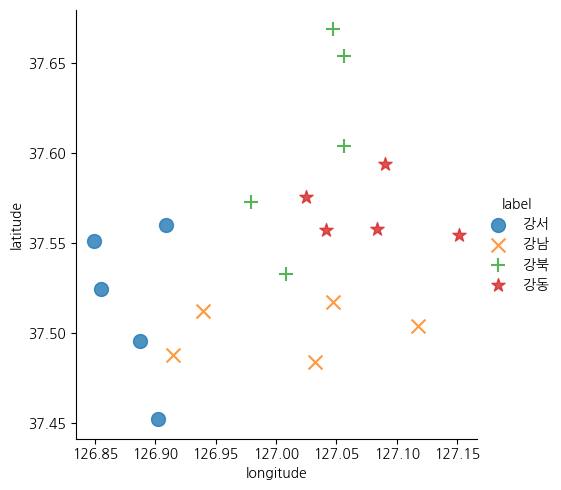

In [17]:
### 경도, 위도에 따른 데이터 시각화

sns.lmplot(
  x='longitude',
  y='latitude',
  data=train_df,
  fit_reg=False,
  scatter_kws={'s' : 100},
  hue='label',
  markers=['o','x','+','*']
)

plt.show()

---
### 데이터 다듬기

In [19]:
train_df.head()

,district,longitude,latitude,label
0,강서구,126.849500,37.551000,강서
1,양천구,126.855396,37.524240,강서
2,구로구,126.887400,37.495400,강서
3,금천구,126.902000,37.451900,강서
4,마포구,126.908728,37.560229,강서


In [20]:
train_df.drop(
  ['district'],
  axis='columns',
  inplace=True
)


test_df.drop(
  ['dong'],
  axis='columns',
  inplace=True
)

In [21]:
trainData = train_df[['longitude','latitude']]
trainTarget = train_df['label']


testData = test_df[['longitude','latitude']]
testTarget = test_df['label']

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [23]:
clf = DecisionTreeClassifier(random_state=42).fit(trainData, trainTarget)


In [24]:
print(clf.score(trainData, trainTarget))
print(clf.score(testData, testTarget))

1.0
1.0


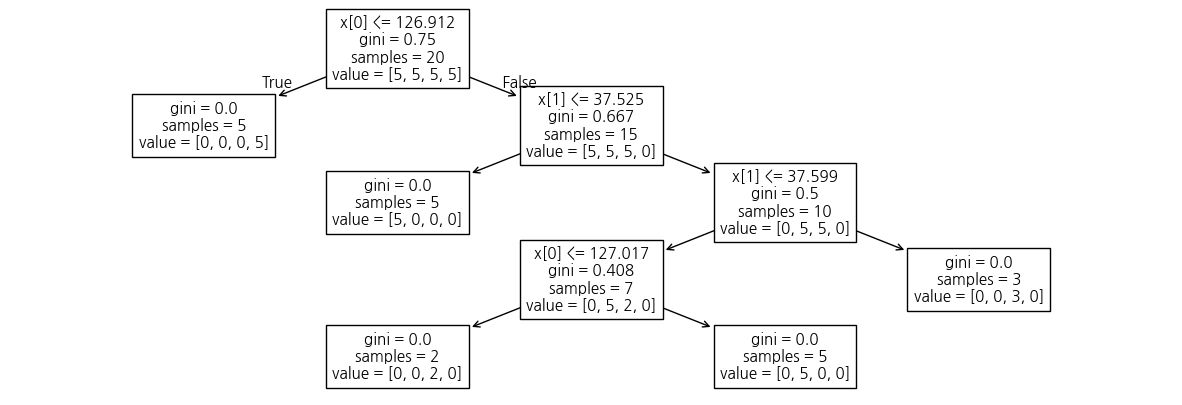

In [29]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15,5))
plot_tree(clf)
plt.show()